# ALSRS — Phase 2, Step 1: Dataset Validation

**MDS650_v260905_alsrs**

Before training the Random Forest models, we validate the dataset that the
collector produced. This notebook is **read-only**: it inspects and plots,
but does not modify the dataset.

What we check here:

1. **Integrity** — shape, columns, missing values, points vs. source CSV.
2. **Target distribution** — the 3 future deficits (percentage 0–100).
3. **Class balance** — after applying the thresholds (LOW/MEDIUM/HIGH/NOT_SUITABLE).
4. **ONI signal** — correlation between `oni` and the deficits.
5. **sample_weight exploration** — inputs to choose the weighting function.

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# This notebook lives in ml/, so the dataset and points CSV are siblings.
ML_DIR = Path.cwd() if Path.cwd().name == "ml" else Path.cwd() / "ml"
DATASET = ML_DIR / "ml_dataset_cacao_ccn51.csv"
POINTS = ML_DIR / "cacao_points.csv"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)

print(f"Dataset : {DATASET}")
print(f"Points  : {POINTS}")

Dataset : /home/wmlegion/Documents/github/ALSRS/ml/ml_dataset_cacao_ccn51.csv
Points  : /home/wmlegion/Documents/github/ALSRS/ml/cacao_points.csv


In [4]:
df = pd.read_csv(DATASET)
print("Shape:", df.shape)
print("Columns (%d):" % len(df.columns))
for c in df.columns:
    print(f"  {c}")

Shape: (52341, 31)
Columns (31):
  point_id
  lat
  lon
  crop
  period_start
  period_end
  label
  month
  biweek
  mean_C
  std_C
  precip_total_mm
  precip_rainy_days
  pet_mm
  spei_1m
  spei_3m
  spei_6m
  spei_12m
  AWC_mm
  Storage_mm
  P_acum_mm
  WRSI
  deficit_pct
  future_deficit_1m
  future_deficit_3m
  future_deficit_6m
  future_deficit_1m_mm
  future_deficit_3m_mm
  future_deficit_6m_mm
  suggestion
  oni


## 1. Integrity checks

In [5]:
# 1a. Missing values per column.
na = df.isna().sum()
print("Columns with NaN:")
print(na[na > 0].to_string() if (na > 0).any() else "  none — every column is complete")

Columns with NaN:
  none — every column is complete


In [6]:
# 1b. Points: dataset vs. the source points CSV.
pts = pd.read_csv(POINTS)
in_dataset = set(df["point_id"].unique())
in_source = set(pts["point_id"])

print(f"Points in cacao_points.csv : {len(in_source)}")
print(f"Points in dataset           : {df['point_id'].nunique()}")
missing = in_source - in_dataset
extra = in_dataset - in_source
print(f"Missing from dataset        : {sorted(missing) if missing else 'none'}")
print(f"Extra (not in source)       : {sorted(extra) if extra else 'none'}")

Points in cacao_points.csv : 240
Points in dataset           : 239
Missing from dataset        : ['p074']
Extra (not in source)       : none


In [7]:
# 1c. Biweekly periods per point (should be constant).
per_point = df.groupby("point_id")["label"].nunique()
print("Biweeks per point:")
print(per_point.describe().to_string())
print(f"\nUnique biweek labels in whole dataset: {df['label'].nunique()}")

Biweeks per point:
count    239.0
mean     219.0
std        0.0
min      219.0
25%      219.0
50%      219.0
75%      219.0
max      219.0

Unique biweek labels in whole dataset: 219


In [8]:
# 1d. Zone distribution (from the source CSV, joined for completeness).
zone_map = pts.set_index("point_id")["zone"]
df["_zone"] = df["point_id"].map(zone_map)
print("Rows per zone:")
print(df["_zone"].value_counts().to_string())
print("\nPoints per zone:")
print(df.groupby("_zone")["point_id"].nunique().to_string())

Rows per zone:
_zone
dry             32850
intermediate     8760
humid            8541
very_humid       2190

Points per zone:
_zone
dry             150
humid            39
intermediate     40
very_humid       10


## 2. Target distribution

The three targets are the accumulated future deficits as fractions 0–1
(`future_deficit_1m/3m/6m`). The `_mm` columns are informative companions
and are **not** targets.

In [9]:
targets = ["future_deficit_1m", "future_deficit_3m", "future_deficit_6m"]

print("Summary statistics (percentage 0-100):")
print(df[targets].describe().T.to_string())

Summary statistics (percentage 0-100):
                     count       mean        std  min  25%   50%    75%     max
future_deficit_1m  52341.0  11.889205  24.446058  0.0  0.0  0.00   6.21  100.00
future_deficit_3m  52341.0  12.119462  19.716936  0.0  0.0  0.00  18.71  100.00
future_deficit_6m  52341.0  12.468104  15.392510  0.0  0.0  5.67  21.93   88.84


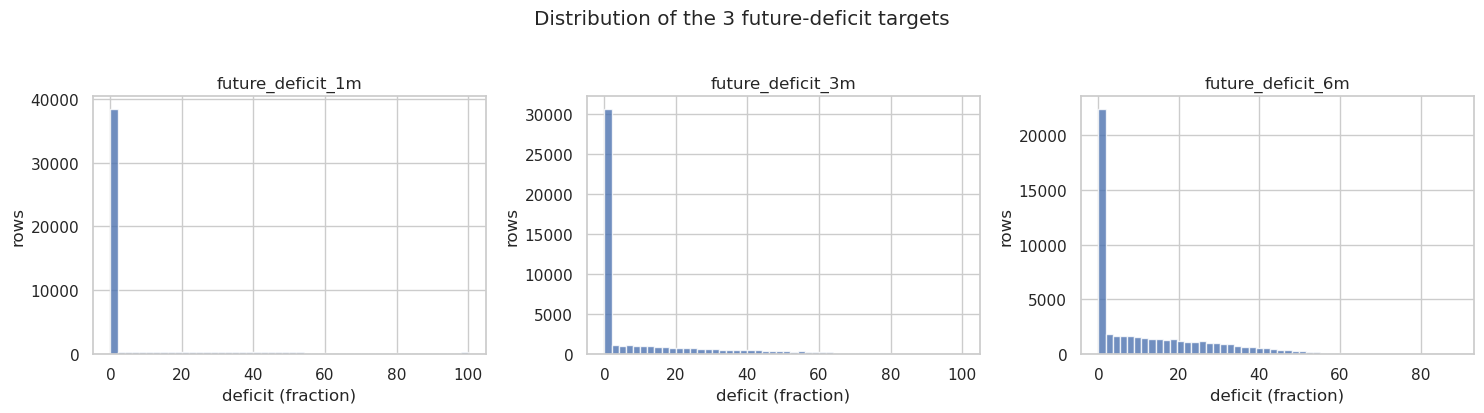

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t in zip(axes, targets):
    ax.hist(df[t], bins=50, color="#4C72B0", alpha=0.8)
    ax.set_title(t)
    ax.set_xlabel("deficit (fraction)")
    ax.set_ylabel("rows")
fig.suptitle("Distribution of the 3 future-deficit targets", y=1.03)
fig.tight_layout()
plt.show()

In [11]:
# Quantiles to see where the mass sits (and how much exceeds each threshold).
q = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
print("Quantiles:")
print(df[targets].quantile(q).T.to_string())

Quantiles:
                   0.01  0.05  0.25  0.50   0.75   0.95    0.99
future_deficit_1m   0.0   0.0   0.0  0.00   6.21  74.58  95.550
future_deficit_3m   0.0   0.0   0.0  0.00  18.71  56.79  78.410
future_deficit_6m   0.0   0.0   0.0  5.67  21.93  43.95  57.266


## 3. Class balance (thresholds applied)

The thresholds are the project's own irrigation policy (not literature):

- `<= 15` → LOW
- `<= 30` → MEDIUM
- `<= 50` → HIGH
- `>  50` → NOT_SUITABLE

The model is **regression**; these classes are derived AFTER prediction.

In [12]:
def classify_deficit(v: float) -> str:
    if pd.isna(v):
        return "NA"
    if v <= 15:
        return "LOW"
    if v <= 30:
        return "MEDIUM"
    if v <= 50:
        return "HIGH"
    return "NOT_SUITABLE"

for t in targets:
    counts = df[t].apply(classify_deficit).value_counts()
    print(f"\n{t}:")
    for cls in ["LOW", "MEDIUM", "HIGH", "NOT_SUITABLE"]:
        n = counts.get(cls, 0)
        pct = 100 * n / len(df)
        print(f"  {cls:<13} {n:>6}  ({pct:5.1f}%)")


future_deficit_1m:
  LOW            40890  ( 78.1%)
  MEDIUM          2599  (  5.0%)
  HIGH            3201  (  6.1%)
  NOT_SUITABLE    5651  ( 10.8%)

future_deficit_3m:
  LOW            37587  ( 71.8%)
  MEDIUM          5758  ( 11.0%)
  HIGH            5146  (  9.8%)
  NOT_SUITABLE    3850  (  7.4%)

future_deficit_6m:
  LOW            34228  ( 65.4%)
  MEDIUM          9979  ( 19.1%)
  HIGH            6797  ( 13.0%)
  NOT_SUITABLE    1337  (  2.6%)


In [13]:
# Balance of the stored suggestion column (worst of the 3 horizons).
print("suggestion (stored, = worst of 3):")
sugg = df["suggestion"].value_counts()
for cls in ["LOW", "MEDIUM", "HIGH", "NOT_SUITABLE"]:
    n = sugg.get(cls, 0)
    print(f"  {cls:<13} {n:>6}  ({100*n/len(df):5.1f}%)")

suggestion (stored, = worst of 3):
  LOW            29723  ( 56.8%)
  MEDIUM          7670  ( 14.7%)
  HIGH            7396  ( 14.1%)
  NOT_SUITABLE    7552  ( 14.4%)


## 4. ONI signal

Does the ENSO index correlate with the future deficits? If yes, it carries
usable signal for the forecast.

In [14]:
corr = df[["oni"] + targets].corr()["oni"].drop("oni")
print("Pearson correlation of oni with each target:")
print(corr.to_string())

Pearson correlation of oni with each target:
future_deficit_1m    0.148358
future_deficit_3m    0.186927
future_deficit_6m    0.208737


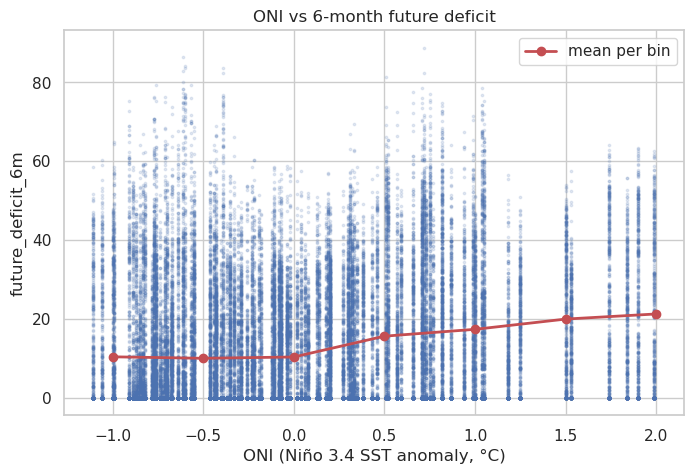

In [15]:
# Scatter: ONI vs 6-month deficit, binned to see the trend.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["oni"], df["future_deficit_6m"], s=3, alpha=0.15, color="#4C72B0")
# bin the x-axis to show the mean trend
bins = np.arange(-1.25, 2.26, 0.5)
df["_oni_bin"] = pd.cut(df["oni"], bins)
means = df.groupby("_oni_bin", observed=True)["future_deficit_6m"].mean()
centers = [iv.mid for iv in means.index]
ax.plot(centers, means.values, "o-", color="#C44E52", linewidth=2, label="mean per bin")
ax.set_xlabel("ONI (Niño 3.4 SST anomaly, °C)")
ax.set_ylabel("future_deficit_6m")
ax.set_title("ONI vs 6-month future deficit")
ax.legend()
plt.show()

## 5. sample_weight exploration

The regression targets are skewed toward low deficits. To make the model
care about the rare HIGH / NOT_SUITABLE cases, we will pass `sample_weight`.
Here we inspect the distribution to choose the weighting function.

In [16]:
# How much of each target sits above the 'interesting' thresholds.
for t in targets:
    frac_high = (df[t] > 30.0).mean()
    frac_crit = (df[t] > 50.0).mean()
    print(f"{t}: >30 = {100*frac_high:.1f}%  |  >50 = {100*frac_crit:.1f}%")

future_deficit_1m: >30 = 16.9%  |  >50 = 10.8%
future_deficit_3m: >30 = 17.2%  |  >50 = 7.4%
future_deficit_6m: >30 = 15.5%  |  >50 = 2.6%


In [17]:
# Candidate weight functions (to compare in Step 3).
#   linear : weight = deficit
#   squared: weight = deficit^2  (emphasizes the tail more)
for t in targets:
    w_lin = df[t]
    w_sq = df[t] ** 2
    print(f"{t}:")
    print(f"  linear  weight: mean={w_lin.mean():.3f}, max={w_lin.max():.3f}")
    print(f"  squared weight: mean={w_sq.mean():.3f}, max={w_sq.max():.3f}")

future_deficit_1m:
  linear  weight: mean=11.889, max=100.000
  squared weight: mean=738.952, max=10000.000
future_deficit_3m:
  linear  weight: mean=12.119, max=100.000
  squared weight: mean=535.631, max=10000.000
future_deficit_6m:
  linear  weight: mean=12.468, max=88.840
  squared weight: mean=392.378, max=7892.546


## Summary

This notebook is the read-only validation of the dataset. The numbers above
feed two decisions for Step 2:

1. **The sample_weight function** (linear vs. squared), based on how skewed
   each target is.
2. **The split ratio** (default 80/20 by point, no zone stratification).

The `p074` point (if reported missing) is a known discrepancy to fix by
re-running the collector for that single point before training.

## Step 2: Feature / target preparation and split

- **Features (17 numeric):** climate, soil, water-balance state and ONI.
  The crop thermal signal is already in `pet_mm` (ET0) and `month`/`biweek`.
  `crop` is excluded because it is constant (`cacao_ccn51`) in this dataset.
- **Targets (3):** `future_deficit_1m/3m/6m` (percentage 0-100), one per
  independent Random Forest regressor.
- **Split by point:** a farm's whole time series goes together (no leakage),
  80/20, fixed seed, no zone stratification.


In [18]:
# Identify columns (not model inputs) and the mm companions (not targets).
ID_COLS = ["point_id", "lat", "lon", "crop", "period_start", "period_end", "label"]

FEATURES = [
    "month", "biweek", "mean_C", "std_C",
    "precip_total_mm", "precip_rainy_days", "pet_mm",
    "spei_1m", "spei_3m", "spei_6m", "spei_12m",
    "AWC_mm", "Storage_mm", "P_acum_mm", "WRSI_1m", "deficit_1m",
    "oni",
]

TARGETS = ["future_deficit_1m", "future_deficit_3m", "future_deficit_6m"]

# mm companions + suggestion are informative, not targets; helper cols from Step 1.
DROP = ["future_deficit_1m_mm", "future_deficit_3m_mm", "future_deficit_6m_mm",
        "suggestion", "_zone", "_oni_bin"]

print("Features:", len(FEATURES))
print("Targets :", len(TARGETS))


Features: 17
Targets : 3


In [19]:
from sklearn.model_selection import train_test_split

# Split the unique FARMS, not the rows (a farm's time series stays together).
point_ids = df["point_id"].unique()
train_pts, test_pts = train_test_split(
    point_ids, test_size=0.20, random_state=42
)

train_mask = df["point_id"].isin(train_pts)
test_mask = df["point_id"].isin(test_pts)

X_train = df.loc[train_mask, FEATURES]
y_train = df.loc[train_mask, TARGETS]
X_test = df.loc[test_mask, FEATURES]
y_test = df.loc[test_mask, TARGETS]

print(f"Train: {len(X_train)} rows from {len(train_pts)} farms")
print(f"Test : {len(X_test)} rows from {len(test_pts)} farms")


Train: 41829 rows from 191 farms
Test : 10512 rows from 48 farms


In [20]:
# sample_weight: weight HIGH deficits more (they are rarer and matter most).
# Each of the 3 models uses the weight built from ITS OWN target column.

def weight_linear(deficit):
    """weight = deficit (0-deficit rows get weight 0 = ignored)."""
    return deficit

def weight_squared(deficit):
    """weight = deficit^2 (emphasizes the tail strongly)."""
    return deficit ** 2

# Show the effect of each weighting on the 1-month target (training set).
col = "future_deficit_1m"
for name, fn in [("linear", weight_linear), ("squared", weight_squared)]:
    w = fn(y_train[col])
    share_high = 100 * w[y_train[col] > 50].sum() / w.sum()
    print(f"{name:8s} -> mean={w.mean():7.2f}  max={w.max():7.2f}  "
          f"weight on >50% rows: {share_high:.1f}%")


linear   -> mean=  11.30  max= 100.00  weight on >50% rows: 65.9%
squared  -> mean= 695.95  max=10000.00  weight on >50% rows: 82.0%


## Next (Step 3, tomorrow)

Train 3 independent `RandomForestRegressor` models (one per horizon), each
with its own `sample_weight`, and a persistence baseline. Then threshold the
predictions with the 15/30/50 rule and derive `suggestion` = worst of 3.


## Step 3: Train Random Forest models (with timing)

Three independent `RandomForestRegressor` models (one per horizon), each
trained with two `sample_weight` variants (linear and squared), against a
**persistence baseline** ("the future will be like today"). Each fit prints
its start and end time so we can measure execution time.


In [ ]:
from datetime import datetime
import time

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix,
    classification_report,
)

# ---- 1. Persistence baseline ---------------------------------------------
# "The next period will be like the current one": predict every future deficit
# as today's current deficit (deficit_1m). Any real model must beat this.
baseline_mae, baseline_rmse = {}, {}
for t in TARGETS:
    baseline_mae[t] = mean_absolute_error(y_test[t], X_test["deficit_1m"])
    baseline_rmse[t] = np.sqrt(mean_squared_error(y_test[t], X_test["deficit_1m"]))

print("Baseline (persistence) — the model must beat these:")
for t in TARGETS:
    print(f"  {t}: MAE={baseline_mae[t]:.2f}  RMSE={baseline_rmse[t]:.2f}")


In [ ]:
# ---- 2. Train 3 horizons x 2 weightings, timing each fit -----------------
WEIGHTS = {"linear": weight_linear, "squared": weight_squared}

rows = []      # collect results for the summary table
models = {}    # keep the trained models for feature importance

for target in TARGETS:
    for wname, wfn in WEIGHTS.items():
        # Fixed, sensible hyperparameters. Tuning is a future (script) step.
        model = RandomForestRegressor(
            n_estimators=300, random_state=42, n_jobs=-1
        )
        w = wfn(y_train[target])   # weight built from THIS target column

        start = datetime.now()
        model.fit(X_train, y_train[target], sample_weight=w)
        end = datetime.now()
        elapsed = (end - start).total_seconds()

        pred = model.predict(X_test)
        mae = mean_absolute_error(y_test[target], pred)
        rmse = np.sqrt(mean_squared_error(y_test[target], pred))

        models[(target, wname)] = model
        rows.append([target, wname, mae, rmse, elapsed])
        print(f"{target} [{wname:8s}]  {start.strftime('%H:%M:%S')} -> "
              f"{end.strftime('%H:%M:%S')}  ({elapsed:6.1f}s)  "
              f"MAE={mae:6.2f}  RMSE={rmse:6.2f}")


In [ ]:
# ---- 3. Summary table: model vs baseline --------------------------------
res = pd.DataFrame(rows, columns=["target", "weight", "mae", "rmse", "elapsed_s"])
res["baseline_mae"] = res["target"].map(baseline_mae)
res["baseline_rmse"] = res["target"].map(baseline_rmse)
res = res.round(2)
print(res.to_string(index=False))


In [ ]:
# ---- 4. Feature importance per horizon (squared weighting) ---------------
# Lets us check the hypothesis that ONI matters more at longer horizons.
imp = pd.DataFrame({"feature": FEATURES})
for t in TARGETS:
    imp[t] = models[(t, "squared")].feature_importances_

# Sort by the 6-month model's importance (descending) for readability.
imp = imp.sort_values("future_deficit_6m", ascending=False).reset_index(drop=True)
print("Feature importance (squared weighting):")
print(imp.round(4).to_string(index=False))


In [ ]:
# ---- 5. Derived classification: does it catch HIGH / NOT_SUITABLE? -------
# Threshold the predictions (squared models) and compare against the true
# worst-of-3 class. We look at recall — NOT overall accuracy, which the many
# LOW rows would inflate.

SEVERITY = {"LOW": 0, "MEDIUM": 1, "HIGH": 2, "NOT_SUITABLE": 3}

def worst_of(*classes):
    """Most severe class among the given ones."""
    return max(classes, key=lambda c: SEVERITY.get(c, -1))

# True and predicted class per horizon (using the squared models).
true_cls = pd.DataFrame({t: y_test[t].apply(classify_deficit) for t in TARGETS})
pred_cls = pd.DataFrame({
    t: pd.Series(models[(t, "squared")].predict(X_test),
                 index=y_test.index).apply(classify_deficit)
    for t in TARGETS
})

true_sugg = true_cls.apply(lambda r: worst_of(*r), axis=1)
pred_sugg = pred_cls.apply(lambda r: worst_of(*r), axis=1)

labels = ["LOW", "MEDIUM", "HIGH", "NOT_SUITABLE"]
cm = confusion_matrix(true_sugg, pred_sugg, labels=labels)
print("Confusion matrix (rows = true, cols = predicted):")
print(pd.DataFrame(cm, index=labels, columns=labels).to_string())
print()
print(classification_report(true_sugg, pred_sugg, labels=labels, zero_division=0))


## Summary (Step 3)

- The model must beat the **persistence baseline** on MAE/RMSE per horizon.
- **`squared` weighting** should give better recall on HIGH/NOT_SUITABLE than
  `linear`, because it concentrates more weight on the rare extreme rows.
- **Feature importance** shows whether ONI's role grows with the horizon.

### Possible follow-ups (as separate scripts, not this notebook)

1. **Hyperparameter tuning** (`GridSearchCV` / `RandomizedSearchCV`).
2. **Cross-validation by point** (more robust than one 80/20 split).
3. **Learning curve** (train on increasing fractions of farms) to answer
   "are 240 farms enough?".
